In [1]:
# Import data
import pandas as pd
import numpy as np 

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge , Lasso
from sklearn.svm import SVR

In [2]:
#Load data
path = "auto-mpg.data"

columns = ["mpg", "cylinders", "displacement", "horsepower",
"weight", "acceleration", "model_year", "origin", "car_name"
]

df = pd.read_csv(
    path,
    sep=r"\s+",
    names=columns,
    na_values="?"
)

# remove header row if exists
df = df[df["mpg"] != "displacement,"]

# convert numeric columns
num_cols = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin"
]
df = df.dropna(subset=["mpg"])

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,"mpg,","cylinders,displacement,","horsepower,","weight,","acceleration,","model_year,","origin,",car_name,NaN
1,18.0,8,307.0,130.0,3504.,12.0,70,1,chevrolet chevelle malibu
2,15.0,8,350.0,165.0,3693.,11.5,70,1,buick skylark 320
3,18.0,8,318.0,150.0,3436.,11.0,70,1,plymouth satellite
4,16.0,8,304.0,150.0,3433.,12.0,70,1,amc rebel sst


In [3]:
#Features / target
X = df.drop(columns=["mpg", "car_name"])
y = df["mpg"]

num_features = [
    "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year"
]

cat_features = ["origin"]

X = df[num_features + cat_features]
y = df["mpg"]

In [4]:
# Target mpg về numeric
y = pd.to_numeric(y, errors="coerce")

# Drop mpg columns not be NaN (header + errors)
mask = y.notna()
y = y[mask]
X = X.loc[mask]

# check again
print(y.dtype)
print(y.isnull().sum())


float64
0


In [5]:
#Preprocessor with no Nan
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)


In [6]:
model = LinearRegression()

pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", model)
])


In [7]:
# Model
models = {
    "Predict-Mean": None,
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "SVR-linear": SVR(kernel="linear"),
    "SVR-RBF": SVR(kernel="rbf", C=10, gamma="scale")
}

In [8]:
# K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae = -cross_val_score(
    pipe, X, y, cv=kf,
    scoring="neg_mean_absolute_error"
).mean()

rmse = np.sqrt(-cross_val_score(
    pipe, X, y, cv=kf,
    scoring="neg_mean_squared_error"
).mean())

r2 = cross_val_score(
    pipe, X, y, cv=kf,
    scoring="r2"
).mean()

mae, rmse, r2



(np.float64(2.5702569598274714),
 np.float64(3.372029872485632),
 np.float64(0.8144915956621649))

In [9]:
print(X.columns.tolist())


['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']


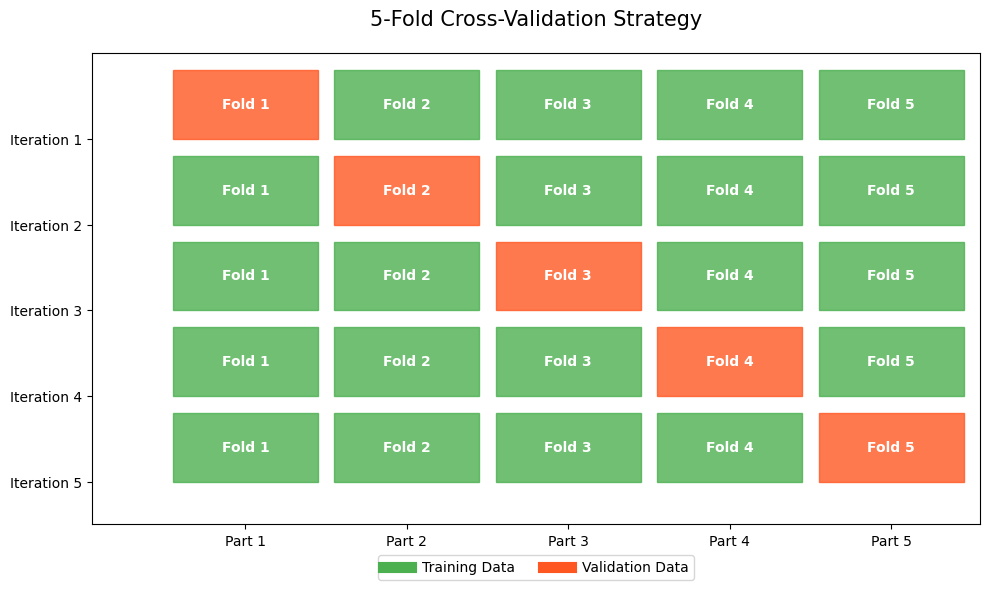

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def draw_cv_diagram():
    fig, ax = plt.subplots(figsize=(10, 6))
    n_folds = 5
    
    # Thiết lập các thuộc tính vẽ
    colors = ['#4CAF50', '#FF5722'] # Xanh cho Training, Cam cho Validation
    labels = ['Training Fold', 'Validation Fold']
    
    for i in range(n_folds):
        # Vẽ 5 khối cho mỗi hàng (mỗi iteration)
        for j in range(n_folds):
            color = colors[1] if i == j else colors[0]
            rect = plt.Rectangle((j, n_folds - i - 1), 0.9, 0.8, color=color, alpha=0.8)
            ax.add_patch(rect)
            
            # Đánh số Fold
            ax.text(j + 0.45, n_folds - i - 0.6, f'Fold {j+1}', 
                    ha='center', va='center', color='white', fontweight='bold')

    # Định dạng trục
    ax.set_xlim(-0.5, n_folds)
    ax.set_ylim(-0.5, n_folds)
    ax.set_xticks(np.arange(n_folds) + 0.45)
    ax.set_xticklabels([f'Part {i+1}' for i in range(n_folds)])
    ax.set_yticks(np.arange(n_folds))
    ax.set_yticklabels([f'Iteration {n_folds-i}' for i in range(n_folds)])
    
    plt.title('5-Fold Cross-Validation Strategy', fontsize=15, pad=20)
    
    # Tạo chú thích (Legend)
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color=colors[0], lw=8, label='Training Data'),
                       Line2D([0], [0], color=colors[1], lw=8, label='Validation Data')]
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)

    plt.tight_layout()
    plt.savefig('cross_validation.png', dpi=300)
    plt.show()

draw_cv_diagram()

C:\Users\khang\AppData\Local\Temp\ipykernel_28700\594137692.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("auto-mpg.data",


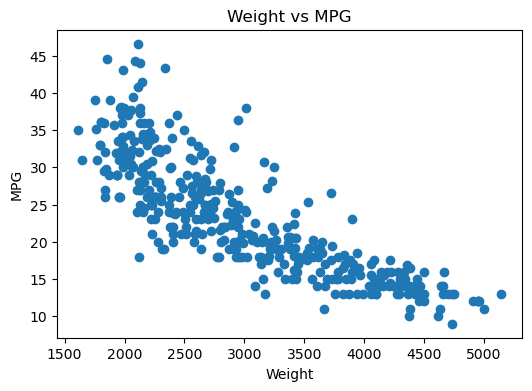

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load đúng cách
df = pd.read_csv("auto-mpg.data",
                 delim_whitespace=True,
                 header=None,
                 names=["mpg","cylinders","displacement","horsepower",
                        "weight","acceleration","model_year","origin","car_name"])

# Convert về numeric
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df['weight'] = pd.to_numeric(df['weight'], errors='coerce')
df['mpg'] = pd.to_numeric(df['mpg'], errors='coerce')

# Drop missing
df = df.dropna()

# Plot lại
plt.figure(figsize=(6,4))
plt.scatter(df['weight'], df['mpg'])
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Weight vs MPG")
plt.show()

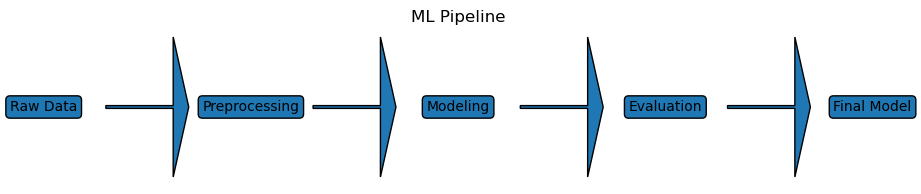

In [12]:
# Flowchart Pipeline
import matplotlib.pyplot as plt

plt.figure(figsize=(10,2))

steps = ["Raw Data", "Preprocessing", "Modeling", "Evaluation", "Final Model"]

for i, step in enumerate(steps):
    plt.text(i, 0, step, ha='center', va='center', fontsize=10,
             bbox=dict(boxstyle="round"))

# vẽ mũi tên
for i in range(len(steps)-1):
    plt.arrow(i+0.3, 0, 0.4, 0, head_width=0.05, length_includes_head=True)

plt.axis('off')
plt.title("ML Pipeline")
plt.show()

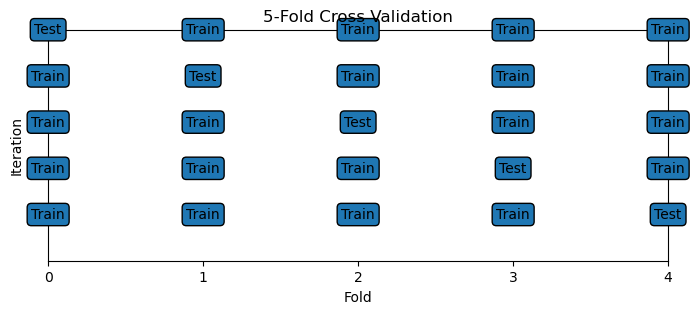

In [13]:
# Cross-validation diagram
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,3))

folds = 5

for i in range(folds):
    for j in range(folds):
        if j == i:
            label = "Test"
        else:
            label = "Train"
        
        ax.text(j, folds-i, label, ha='center', va='center',
                bbox=dict(boxstyle="round"))

ax.set_xticks(range(folds))
ax.set_yticks(range(1, folds+1))
ax.set_title("5-Fold Cross Validation")
ax.set_xlabel("Fold")
ax.set_ylabel("Iteration")

plt.show()